In [62]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import lightgbm as lgb

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

DATA_DIR = Path('./data')
print('Environment ready ✓')

Environment ready ✓


## 1. Data Loading

In [63]:
df_pgcb = pd.read_excel('/content/PGCB_date_power_demand.xlsx', parse_dates=['datetime'])
print(f'PGCB raw shape : {df_pgcb.shape}')
print(f'Date range     : {df_pgcb.datetime.min()} → {df_pgcb.datetime.max()}')
print(f'Duplicates     : {df_pgcb.datetime.duplicated().sum()}')
df_pgcb.head(3)

PGCB raw shape : (92650, 15)
Date range     : 2015-04-19 00:00:00 → 2025-06-17 12:00:00
Duplicates     : 432


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN


In [64]:

_raw = pd.read_excel('/content/weather_data.xlsx', header=None)
_cols = _raw.iloc[3].tolist()
df_weather_raw = _raw.iloc[4:].copy()
df_weather_raw.columns = _cols
df_weather_raw = df_weather_raw.reset_index(drop=True)
print(f'Weather raw shape : {df_weather_raw.shape}')
print(df_weather_raw.dtypes)
df_weather_raw.head(3)

Weather raw shape : (107304, 10)
time                              object
temperature_2m (°C)               object
relative_humidity_2m (%)          object
apparent_temperature (°C)         object
precipitation (mm)                object
dew_point_2m (°C)                 object
soil_temperature_0_to_7cm (°C)    object
wind_direction_10m (°)            object
cloud_cover (%)                   object
sunshine_duration (s)             object
dtype: object


,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0,12.1,16.4,313,0,0
1,2014-01-01 01:00:00,13.6,91,13.2,0,12.1,16,317,0,0
2,2014-01-01 02:00:00,13.3,91,12.8,0,11.9,15.7,317,0,0


In [65]:

df_econ_raw = pd.read_csv('/content/economic_full_1.csv')
print(f'Economic shape : {df_econ_raw.shape}')
print(f'Country        : {df_econ_raw["Country Name"].unique()}')
df_econ_raw[['Indicator Name','2018','2019','2020','2021','2022']].head(5)

Economic shape : (1516, 69)
Country        : ['X']


,Indicator Name,2018,2019,2020,2021,2022
0,"Intentional homicides, male (per 100,000 male)",NaN,NaN,NaN,NaN,NaN
1,Battle-related deaths (number of people),NaN,NaN,2.000000,NaN,2.000000
2,Voice and Accountability: Percentile Rank,27.184465,26.570047,26.570047,28.019323,28.019323
3,Transport services (% of commercial service ex...,22.048898,19.559759,22.257010,27.162699,25.520411
4,"Computer, communications and other services (%...",62.313903,63.578283,67.395621,64.565856,63.537174


In [66]:

df = df_pgcb.copy()
df = df.sort_values('datetime').reset_index(drop=True)


n_dup = df.datetime.duplicated().sum()
df = df.drop_duplicates(subset='datetime', keep='first')
print(f'Removed {n_dup} duplicate timestamps')


df = df.set_index('datetime')
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='1h')
df = df.reindex(full_range)
df.index.name = 'datetime'


df['demand_mw'] = df['demand_mw'].fillna(method='ffill', limit=2)

print(f'After reindex: {df.shape[0]:,} hourly rows')
print(f'Missing demand rows: {df["demand_mw"].isna().sum()}')

Removed 432 duplicate timestamps
After reindex: 89,101 hourly rows
Missing demand rows: 777


In [67]:


def rolling_iqr_clean(series: pd.Series, window: int = 72, k: float = 4.0) -> pd.Series:
    """Replace extreme outliers with rolling median."""
    s = series.copy()
    roll = s.rolling(window, center=True, min_periods=window // 2)
    q1   = roll.quantile(0.25)
    q3   = roll.quantile(0.75)
    med  = roll.median()
    iqr  = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    mask = (s < lower) | (s > upper)
    print(f'  Anomalies detected: {mask.sum()} ({mask.mean()*100:.2f}% of series)')
    s[mask] = med[mask]
    return s

print('Before cleaning — demand_mw stats:')
print(df['demand_mw'].describe().round(1))

df['demand_mw'] = rolling_iqr_clean(df['demand_mw'], window=72, k=4.0)

print('\nAfter cleaning — demand_mw stats:')
print(df['demand_mw'].describe().round(1))

Before cleaning — demand_mw stats:
count     88324.0
mean       8774.0
std        2709.5
min           6.0
25%        6767.0
50%        8379.0
75%       10588.0
max      121000.0
Name: demand_mw, dtype: float64
  Anomalies detected: 44 (0.05% of series)

After cleaning — demand_mw stats:
count    88324.0
mean      8772.6
std       2606.9
min          6.0
25%       6769.0
50%       8381.0
75%      10590.2
max      17200.0
Name: demand_mw, dtype: float64


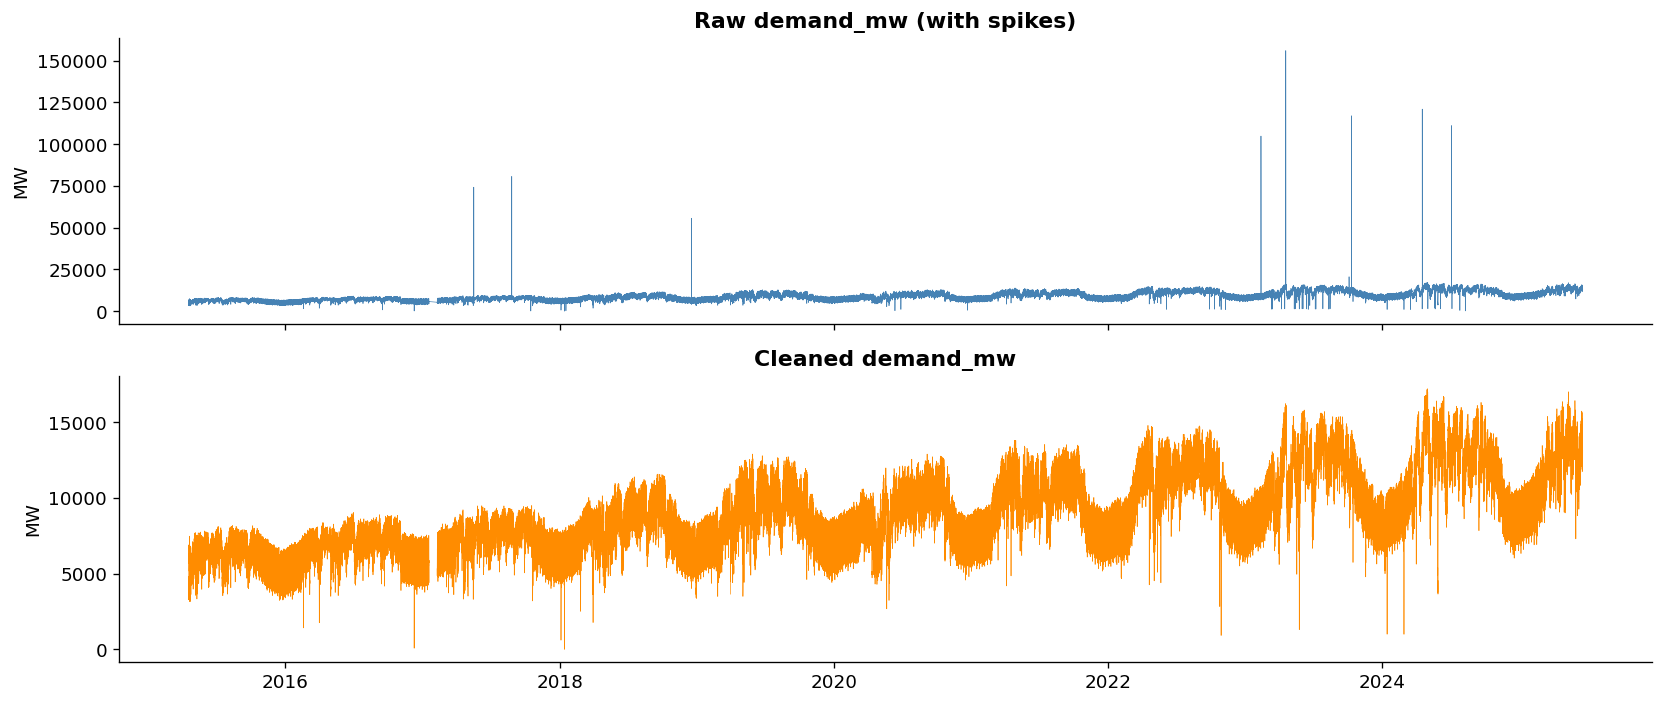

Figure saved.


In [68]:

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
orig = df_pgcb.set_index('datetime').sort_index()['demand_mw']
axes[0].plot(orig.index, orig.values, lw=0.4, color='steelblue')
axes[0].set_title('Raw demand_mw (with spikes)', fontweight='bold')
axes[1].plot(df.index, df['demand_mw'].values, lw=0.4, color='darkorange')
axes[1].set_title('Cleaned demand_mw', fontweight='bold')
for ax in axes:
    ax.set_ylabel('MW')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('fig_raw_vs_clean.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

In [69]:

df_w = df_weather_raw.copy()
df_w['datetime'] = pd.to_datetime(df_w['time'], errors='coerce')
df_w = df_w.dropna(subset=['datetime'])
df_w = df_w.set_index('datetime').drop(columns=['time'])


df_w.columns = [
    'temperature', 'humidity', 'apparent_temp',
    'precipitation', 'dew_point', 'soil_temp',
    'wind_dir', 'cloud_cover', 'sunshine_sec'
]
df_w = df_w.apply(pd.to_numeric, errors='coerce')
df_w = df_w[~df_w.index.duplicated(keep='first')]

print(f'Weather shape: {df_w.shape}')
print(f'Weather range: {df_w.index.min()} → {df_w.index.max()}')
print(f'Missing values:\n{df_w.isna().sum()}')

Weather shape: (107304, 9)
Weather range: 2014-01-01 00:00:00 → 2026-03-29 23:00:00
Missing values:
temperature      0
humidity         0
apparent_temp    0
precipitation    0
dew_point        0
soil_temp        0
wind_dir         0
cloud_cover      0
sunshine_sec     0
dtype: int64


In [70]:


ECON_INDICATORS = [
    'GDP growth (annual %)',
    'Population, total',
    'Urban population',
    'Access to electricity (% of population)',
    'Inflation, consumer prices (annual %)',
    'Energy use (kg of oil equivalent) per $1,000 GDP (constant 2021 PPP)',
]

year_cols = [c for c in df_econ_raw.columns if str(c).isdigit() and int(str(c)) >= 2014]
df_econ_sel = df_econ_raw[df_econ_raw['Indicator Name'].isin(ECON_INDICATORS)][['Indicator Name'] + year_cols].copy()

df_econ_sel = df_econ_sel.set_index('Indicator Name')[year_cols].T
df_econ_sel.index = df_econ_sel.index.astype(int)
df_econ_sel.index.name = 'year'

df_econ_sel = df_econ_sel.sort_index().fillna(method='ffill')
df_econ_sel.columns = [
    'econ_elec_access', 'econ_energy_intensity',
    'econ_gdp_growth', 'econ_inflation_cpi',
    'econ_population', 'econ_urban_pop'
]
print(df_econ_sel.round(2))

      econ_elec_access  econ_energy_intensity  econ_gdp_growth  \
year                                                             
2014        46116983.0                   6.99            44.21   
2015        47081010.0                   6.19            44.41   
2016        48043194.0                   5.51            45.04   
2017        48982779.0                   5.70            43.44   
2018        49903270.0                   5.54            40.34   
2019        50830886.0                   5.59            39.97   
2020        51746778.0                   5.69            38.78   
2021        52643565.0                   5.55            39.31   
2022        53650523.0                   7.70            37.67   
2023        55140091.0                   9.88            37.67   
2024        56717264.0                  10.47            37.67   
2025        56717264.0                  10.47            37.67   

      econ_inflation_cpi  econ_population  econ_urban_pop  
year           

In [71]:

df_main = df[['demand_mw', 'generation_mw', 'load_shedding',
              'gas', 'liquid_fuel', 'coal', 'hydro',
              'solar', 'wind']].copy()

df_main = df_main.join(df_w, how='left')


df_main['year'] = df_main.index.year
df_main = df_main.merge(df_econ_sel, on='year', how='left')
df_main.index = df.index
df_main = df_main.drop(columns=['year'])

weather_cols = df_w.columns.tolist()
df_main[weather_cols] = df_main[weather_cols].interpolate('linear', limit=6, limit_direction='forward')
df_main[weather_cols] = df_main[weather_cols].fillna(method='ffill').fillna(method='bfill')

print(f'Merged shape: {df_main.shape}')
print(f'Remaining NaN per column:')
print(df_main.isna().sum()[df_main.isna().sum() > 0])

Merged shape: (89101, 24)
Remaining NaN per column:
demand_mw          777
generation_mw     1055
load_shedding     1055
gas               1055
liquid_fuel       1055
coal              1055
hydro             1055
solar            21572
wind             71192
dtype: int64


In [72]:

df_feat = df_main.copy()

df_feat['hour']        = df_feat.index.hour
df_feat['day_of_week'] = df_feat.index.dayofweek
df_feat['month']       = df_feat.index.month
df_feat['quarter']     = df_feat.index.quarter
df_feat['day_of_year'] = df_feat.index.dayofyear
df_feat['week_of_year']= df_feat.index.isocalendar().week.astype(int)
df_feat['is_weekend']  = (df_feat['day_of_week'] >= 5).astype(int)
df_feat['is_friday']   = (df_feat['day_of_week'] == 4).astype(int)

for col, period in [('hour', 24), ('day_of_week', 7), ('month', 12), ('day_of_year', 365)]:
    df_feat[f'{col}_sin'] = np.sin(2 * np.pi * df_feat[col] / period)
    df_feat[f'{col}_cos'] = np.cos(2 * np.pi * df_feat[col] / period)

print('Calendar features added.')

Calendar features added.


In [73]:


LAGS = [1, 2, 3, 6, 12,
        24, 48,
        24*7,
        24*14]

for lag in LAGS:
    df_feat[f'lag_{lag}h'] = df_feat['demand_mw'].shift(lag)


df_feat['demand_diff_1h']  = df_feat['demand_mw'].diff(1)
df_feat['demand_diff_24h'] = df_feat['demand_mw'].diff(24)

print('Lag features added.')

Lag features added.


In [74]:

WINDOWS = [3, 6, 12, 24, 48, 24*7]

for w in WINDOWS:
    roll = df_feat['demand_mw'].shift(1).rolling(w, min_periods=w//2)
    df_feat[f'roll_mean_{w}h']  = roll.mean()
    df_feat[f'roll_std_{w}h']   = roll.std()
    df_feat[f'roll_max_{w}h']   = roll.max()
    df_feat[f'roll_min_{w}h']   = roll.min()


df_feat['demand_ratio_24h'] = df_feat['demand_mw'] / (df_feat['roll_mean_24h'] + 1e-6)

print('Rolling aggregate features added.')

Rolling aggregate features added.


In [75]:

df_feat['target'] = df_feat['demand_mw'].shift(-1)


df_feat = df_feat.dropna(subset=['target', 'lag_1h', 'lag_24h'])

print(f'Feature matrix shape (after NaN drop): {df_feat.shape}')
print(f'Target range: {df_feat["target"].min():.0f} – {df_feat["target"].max():.0f} MW')

Feature matrix shape (after NaN drop): (87963, 77)
Target range: 6 – 17200 MW


In [76]:

DROP_FROM_X = ['target', 'demand_mw', 'remarks']
FEATURES = [c for c in df_feat.columns if c not in DROP_FROM_X]
print(f'Total features: {len(FEATURES)}')
print(FEATURES)

Total features: 75
['generation_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'temperature', 'humidity', 'apparent_temp', 'precipitation', 'dew_point', 'soil_temp', 'wind_dir', 'cloud_cover', 'sunshine_sec', 'econ_elec_access', 'econ_energy_intensity', 'econ_gdp_growth', 'econ_inflation_cpi', 'econ_population', 'econ_urban_pop', 'hour', 'day_of_week', 'month', 'quarter', 'day_of_year', 'week_of_year', 'is_weekend', 'is_friday', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_168h', 'lag_336h', 'demand_diff_1h', 'demand_diff_24h', 'roll_mean_3h', 'roll_std_3h', 'roll_max_3h', 'roll_min_3h', 'roll_mean_6h', 'roll_std_6h', 'roll_max_6h', 'roll_min_6h', 'roll_mean_12h', 'roll_std_12h', 'roll_max_12h', 'roll_min_12h', 'roll_mean_24h', 'roll_std_24h', 'roll_max_24h', 'roll_min_24h', 'roll_mean_48h', 'roll_s

## 4. Train / Test Split (Strict Chronological)

In [77]:

TEST_YEAR = 2023

train = df_feat[df_feat.index.year < TEST_YEAR].copy()
test  = df_feat[df_feat.index.year == TEST_YEAR].copy()

X_train = train[FEATURES].fillna(method='ffill').fillna(0)
y_train = train['target']

X_test  = test[FEATURES].fillna(method='ffill').fillna(0)
y_test  = test['target']

print(f'Train: {X_train.shape[0]:,} rows  ({train.index.min().date()} → {train.index.max().date()})')
print(f'Test : {X_test.shape[0]:,}  rows  ({test.index.min().date()} → {test.index.max().date()})')

Train: 66,399 rows  (2015-04-20 → 2022-12-31)
Test : 8,760  rows  (2023-01-01 → 2023-12-31)


In [78]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def eval_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    m    = mape(y_te, pred)
    mae  = mean_absolute_error(y_te, pred)
    mse  = mean_squared_error(y_te, pred)
    rmse = np.sqrt(mse)
    print(f'{name:30s}  MAPE={m:.3f}%   MAE={mae:.1f} MW   RMSE={rmse:.1f} MW')
    return pred, m

In [79]:

xgb_model = xgb.XGBRegressor(
    n_estimators=800, learning_rate=0.05, max_depth=7,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_lambda=1.0, n_jobs=-1, random_state=42,
    tree_method='hist', eval_metric='mape'
)
xgb_pred, xgb_mape = eval_model('XGBoost', xgb_model, X_train, y_train, X_test, y_test)

XGBoost                         MAPE=2.560%   MAE=274.2 MW   RMSE=426.4 MW


In [80]:

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.04, max_depth=8,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=20, reg_lambda=1.0,
    n_jobs=-1, random_state=42, verbose=-1
)
lgb_pred, lgb_mape = eval_model('LightGBM (primary)', lgb_model, X_train, y_train, X_test, y_test)

LightGBM (primary)              MAPE=2.325%   MAE=243.6 MW   RMSE=391.1 MW


In [81]:

results = pd.DataFrame({
    'Model':      ['XGBoost', 'LightGBM'],
    'MAPE (%)':   [xgb_mape, lgb_mape],
    'MAE (MW)':   [mean_absolute_error(y_test, p) for p in [xgb_pred, lgb_pred]],
    'RMSE (MW)':  [mean_squared_error(y_test, p) for p in [xgb_pred, lgb_pred]]
}).round(3)
results = results.sort_values('MAPE (%)')
print(results.to_string(index=False))

   Model  MAPE (%)  MAE (MW)  RMSE (MW)
LightGBM     2.325   243.573 152942.086
 XGBoost     2.560   274.230 181783.746


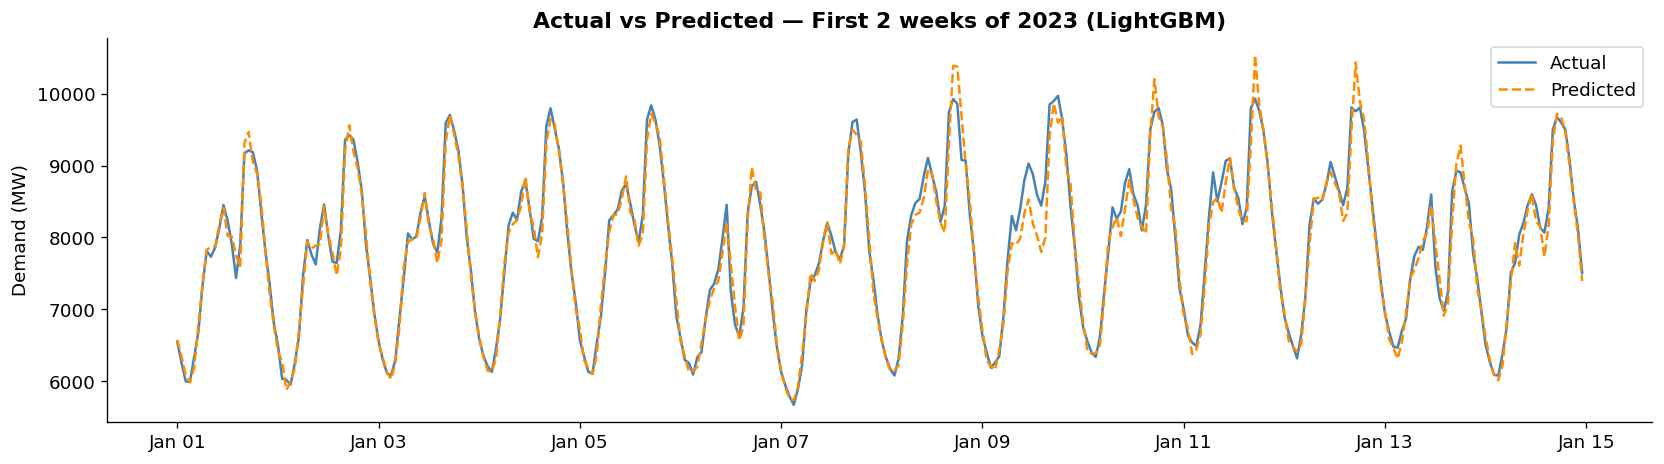

In [82]:

best_preds = lgb_pred


plot_df = test.copy()
plot_df['predicted'] = best_preds
subset  = plot_df.iloc[:24*14]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(subset.index, subset['target'],    label='Actual',    color='steelblue', lw=1.5)
ax.plot(subset.index, subset['predicted'], label='Predicted', color='darkorange', lw=1.5, ls='--')
ax.set_title('Actual vs Predicted — First 2 weeks of 2023 (LightGBM)', fontweight='bold')
ax.set_ylabel('Demand (MW)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend()
plt.tight_layout()
plt.savefig('fig_pred_vs_actual.png', bbox_inches='tight')
plt.show()

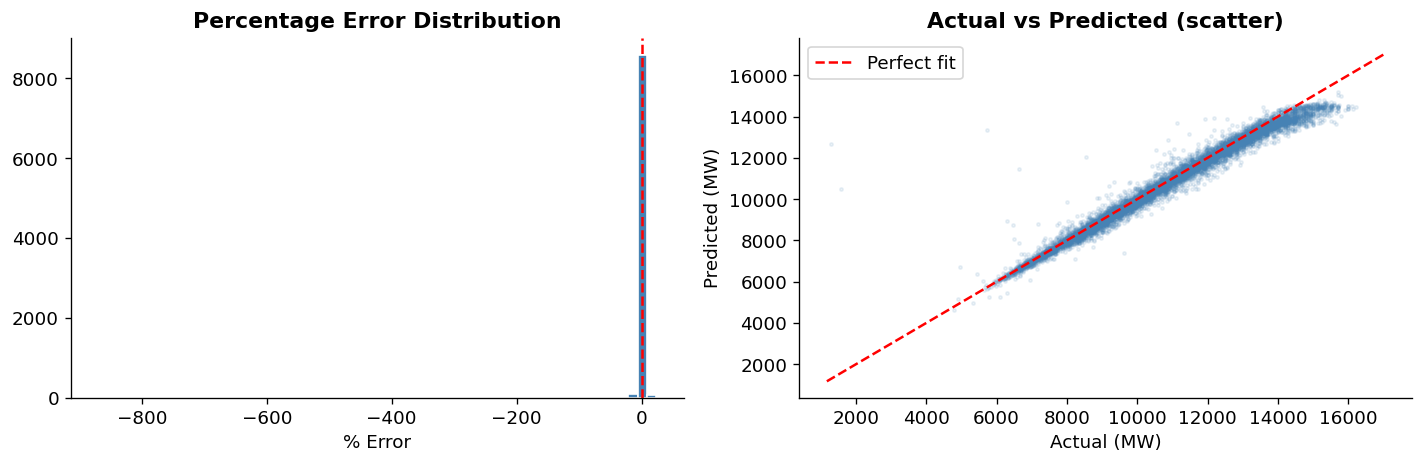

In [83]:

errors = y_test.values - best_preds
pct_err = (errors / y_test.values) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pct_err, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', lw=1.5, ls='--')
axes[0].set_xlabel('% Error')
axes[0].set_title('Percentage Error Distribution', fontweight='bold')

axes[1].scatter(y_test.values, best_preds, alpha=0.1, s=4, color='steelblue')
lims = [y_test.min()*0.9, y_test.max()*1.05]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual (MW)')
axes[1].set_ylabel('Predicted (MW)')
axes[1].set_title('Actual vs Predicted (scatter)', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('fig_error_dist.png', bbox_inches='tight')
plt.show()

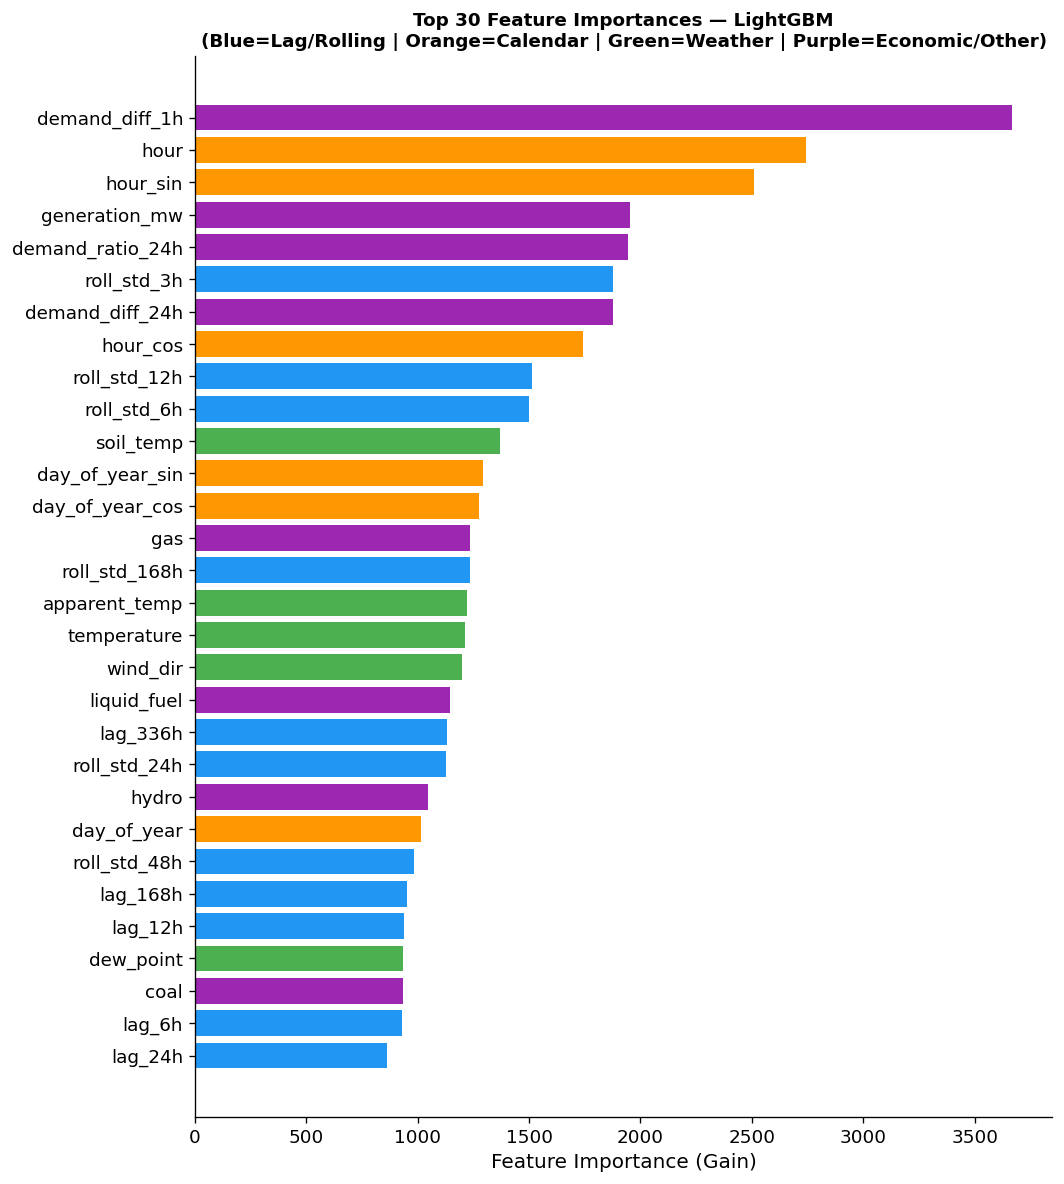


Top 15 features:
         feature  importance
  demand_diff_1h        3666
            hour        2742
        hour_sin        2511
   generation_mw        1955
demand_ratio_24h        1944
     roll_std_3h        1878
 demand_diff_24h        1875
        hour_cos        1744
    roll_std_12h        1513
     roll_std_6h        1499
       soil_temp        1369
 day_of_year_sin        1294
 day_of_year_cos        1277
             gas        1235
   roll_std_168h        1233


In [84]:

fi = pd.DataFrame({'feature': FEATURES,
                   'importance': lgb_model.feature_importances_})
fi = fi.sort_values('importance', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(9, 10))
colors = ['#2196F3' if 'lag' in f or 'roll' in f
          else '#FF9800' if any(k in f for k in ['hour', 'day', 'month', 'week', 'sin', 'cos', 'weekend', 'friday'])
          else '#4CAF50' if any(k in f for k in ['temp', 'humid', 'prec', 'cloud', 'sun', 'wind', 'dew', 'soil', 'apparent'])
          else '#9C27B0'
          for f in fi['feature']]

bars = ax.barh(fi['feature'], fi['importance'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
ax.set_title('Top 30 Feature Importances — LightGBM\n(Blue=Lag/Rolling | Orange=Calendar | Green=Weather | Purple=Economic/Other)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()
print('\nTop 15 features:')
print(fi.head(15).to_string(index=False))

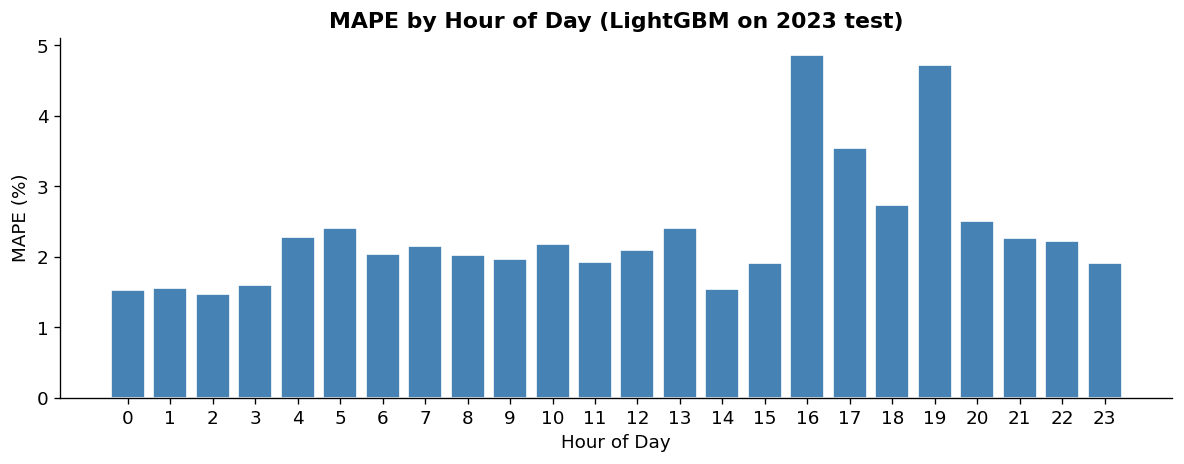

In [85]:

plot_df['hour'] = plot_df.index.hour
hourly_mape = plot_df.groupby('hour').apply(
    lambda g: mape(g['target'], g['predicted'])
).reset_index()
hourly_mape.columns = ['hour', 'mape']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly_mape['hour'], hourly_mape['mape'], color='steelblue', edgecolor='white')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE by Hour of Day (LightGBM on 2023 test)', fontweight='bold')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig('fig_mape_by_hour.png', bbox_inches='tight')
plt.show()

In [86]:
print('='*55)
print('  FINAL TEST MAPE RESULTS  (test year: 2023)')
print('='*55)
for _, row in results.sort_values('MAPE (%)').iterrows():
    print(f"  {row['Model']:25s}  MAPE = {row['MAPE (%)']:.3f}%")
print('='*55)

best_model_name = results.sort_values('MAPE (%)').iloc[0]['Model']
best_mape       = results.sort_values('MAPE (%)').iloc[0]['MAPE (%)']
print(f'\n★ Best single model : {best_model_name}')
print(f'★ Best test MAPE    : {best_mape:.3f}%')
print()
print('Interpretation:')
if best_mape < 3:
    print('  Excellent — < 3% MAPE is publication-quality for grid forecasting.')
elif best_mape < 5:
    print('  Very good — < 5% MAPE is operationally useful for dispatch planning.')
elif best_mape < 10:
    print('  Good — < 10% MAPE is acceptable for day-ahead scheduling.')
else:
    print('  Room for improvement — consider additional feature engineering.')

  FINAL TEST MAPE RESULTS  (test year: 2023)
  LightGBM                   MAPE = 2.325%
  XGBoost                    MAPE = 2.560%

★ Best single model : LightGBM
★ Best test MAPE    : 2.325%

Interpretation:
  Excellent — < 3% MAPE is publication-quality for grid forecasting.
